# Этап 3: Тестирование системы

Этот ноутбук содержит полное тестирование системы:
- Базовые эксперименты после разработки системы
- Сравнительное тестирование различных методов
- Долгосрочная оценка полезности
- Анализ результатов

In [1]:
# Импорт необходимых библиотек
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Импорт модулей проекта
import sys
sys.path.append('../')

from src.data.loaders import load_all_data
from src.data.dataset import ITMDataset
from src.models.deepfm_svdpp import DeepFMSVDPlusPlus
from src.models.dueling_dqn import DuelingDQN
from src.environment.educational_env import EducationalEnvironment
from src.training.replay_buffer import PrioritizedReplayBuffer
from src.training.trainer import DQNTrainer
from src.training.config import TRAIN_CONFIG, DEEPFM_CONFIG, REPLAY_BUFFER_CONFIG
from src.evaluation.experiment_runner import ExperimentRunner
from src.evaluation.comparative_tester import ComparativeTester
from src.evaluation.long_term_evaluator import LongTermEvaluator
from src.utils.helpers import set_seed, load_model

# Установка seed
set_seed(42)

# Определение устройства
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Используется устройство: {device}")

Используется устройство: cpu


## 1. Загрузка данных и моделей

In [2]:
# Загрузка данных
import os
if os.path.exists('../data/processed/ratings_processed.csv'):
    print("Загрузка обработанных данных...")
    ratings = pd.read_csv('../data/processed/ratings_processed.csv')
    users = pd.read_csv('../data/processed/users_processed.csv')
    items = pd.read_csv('../data/processed/items_processed.csv')
else:
    print("Загрузка данных с Kaggle...")
    from src.data.loaders import download_kaggle_dataset
    data_path = download_kaggle_dataset("irecsys/itmrec", "../data/raw")
    data = load_all_data(data_path)
    ratings = data['ratings']
    users = data['users']
    items = data['items']

# Создание датасета
dataset = ITMDataset(ratings, users, items)

# Загрузка предобученной модели DeepFM+SVD++
print("\nЗагрузка модели DeepFM+SVD++...")
checkpoint = torch.load(
    '../data/models/deepfm_svdplusplus_best.pth',
    map_location=device,
    weights_only=False
)

model = DeepFMSVDPlusPlus(
    n_users=dataset.n_users,
    n_items=dataset.n_items,
    n_classes=dataset.n_classes,
    n_semesters=dataset.n_semesters,
    n_lockdowns=dataset.n_lockdowns,
    device=device,
    embedding_dim=DEEPFM_CONFIG['embedding_dim'],
    hidden_dims=DEEPFM_CONFIG['hidden_dims'],
    dropout_rate=DEEPFM_CONFIG['dropout']
)
model.load_state_dict(checkpoint['model_state_dict'])
model.eval()
print("  ✓ Модель загружена")

# Создание среды
print("\nСоздание среды...")
env = EducationalEnvironment(ratings, users, items, model, dataset)
print("  ✓ Среда создана")

Загрузка обработанных данных...
Датасет инициализирован:
  Пользователей: 454
  Предметов: 70
  Классов: 3
  Семестров: 2
  Периодов COVID: 3
  Записей рейтингов: 5230

Загрузка модели DeepFM+SVD++...
  ✓ Модель загружена

Создание среды...
Инициализация кэшей...
Кэши инициализированы: 454 пользователей, 70 предметов
  ✓ Среда создана


## 2. Создание и обучение DQN агента

In [3]:
# Создание DQN агента
state_dim = 65
action_dim = dataset.n_items

dqn_agent = DuelingDQN(
    state_dim,
    action_dim,
    hidden_dims=[256, 128, 64],
    device=device
)

# Загрузка обученного агента (если есть)
if os.path.exists('../data/models/dqn_agent_checkpoint.pth'):
    print("Загрузка обученного DQN агента...")
    trainer_checkpoint = torch.load(
        '../data/models/dqn_agent_checkpoint.pth',
        map_location=device,
        weights_only=False
    )
    dqn_agent.load_state_dict(trainer_checkpoint['agent_state_dict'])
    print("  ✓ Агент загружен")
else:
    print("Обучение DQN агента...")
    # Создание буфера и тренера
    replay_buffer = PrioritizedReplayBuffer(
        capacity=REPLAY_BUFFER_CONFIG['capacity'],
        alpha=REPLAY_BUFFER_CONFIG['alpha'],
        beta=REPLAY_BUFFER_CONFIG['beta']
    )
    
    trainer = DQNTrainer(env, dqn_agent, replay_buffer, TRAIN_CONFIG)
    
    # Обучение на небольшом количестве эпизодов для тестирования
    experiment_runner = ExperimentRunner(trainer, env)
    training_results = experiment_runner.run_training_experiment(
        n_episodes=50,  # Для тестирования
        eval_interval=10
    )
    
    # Сохранение
    trainer.save_checkpoint('../data/models/dqn_agent_checkpoint.pth')
    print("  ✓ Агент обучен и сохранен")

Загрузка обученного DQN агента...
  ✓ Агент загружен


## 3. Базовые эксперименты

Инициализация тренера на cpu
  Gamma: 0.99
  Learning rate: 0.001
  Batch size: 64
  Epsilon: 1.0 → 0.01
Чекпоинт загружен: ../data/models/dqn_agent_checkpoint.pth

----------------------------------------
ЭКСПЕРИМЕНТ 1: ОБУЧЕНИЕ АГЕНТА
----------------------------------------
Запуск обучения на 100 эпизодов...


  7%|▋         | 7/100 [00:00<00:01, 67.04it/s]

Эпизод начат: User 387, Context {'class': 0, 'semester': 0, 'lockdown': 2}
Эпизод начат: User 419, Context {'class': 1, 'semester': 0, 'lockdown': 1}
Эпизод начат: User 370, Context {'class': 0, 'semester': 1, 'lockdown': 2}
Эпизод начат: User 182, Context {'class': 2, 'semester': 1, 'lockdown': 1}
Эпизод начат: User 282, Context {'class': 0, 'semester': 1, 'lockdown': 2}
Эпизод начат: User 188, Context {'class': 2, 'semester': 0, 'lockdown': 0}
Эпизод начат: User 348, Context {'class': 1, 'semester': 0, 'lockdown': 1}
Эпизод начат: User 149, Context {'class': 2, 'semester': 1, 'lockdown': 2}
Эпизод начат: User 91, Context {'class': 0, 'semester': 0, 'lockdown': 2}
Эпизод начат: User 34, Context {'class': 0, 'semester': 1, 'lockdown': 2}
Эпизод начат: User 322, Context {'class': 0, 'semester': 0, 'lockdown': 2}
Эпизод начат: User 432, Context {'class': 2, 'semester': 1, 'lockdown': 2}
Эпизод начат: User 437, Context {'class': 2, 'semester': 0, 'lockdown': 1}
Эпизод начат: User 147, Con

 14%|█▍        | 14/100 [00:00<00:01, 48.14it/s]

Эпизод начат: User 35, Context {'class': 0, 'semester': 0, 'lockdown': 2}
Эпизод начат: User 440, Context {'class': 2, 'semester': 1, 'lockdown': 1}
Эпизод начат: User 83, Context {'class': 0, 'semester': 0, 'lockdown': 2}
Эпизод начат: User 124, Context {'class': 0, 'semester': 0, 'lockdown': 2}
Эпизод начат: User 225, Context {'class': 0, 'semester': 0, 'lockdown': 2}
Эпизод начат: User 165, Context {'class': 1, 'semester': 0, 'lockdown': 2}
Эпизод начат: User 337, Context {'class': 0, 'semester': 0, 'lockdown': 0}
Эпизод начат: User 380, Context {'class': 0, 'semester': 0, 'lockdown': 2}
Эпизод начат: User 125, Context {'class': 0, 'semester': 0, 'lockdown': 2}
Эпизод начат: User 189, Context {'class': 0, 'semester': 0, 'lockdown': 2}


...

 98%|█████████▊| 98/100 [00:06<00:00, 13.36it/s]

Эпизод начат: User 363, Context {'class': 0, 'semester': 0, 'lockdown': 2}
Эпизод начат: User 79, Context {'class': 0, 'semester': 0, 'lockdown': 2}
Эпизод начат: User 434, Context {'class': 2, 'semester': 0, 'lockdown': 1}
Эпизод начат: User 32, Context {'class': 2, 'semester': 1, 'lockdown': 1}
Эпизод начат: User 446, Context {'class': 0, 'semester': 0, 'lockdown': 2}
Эпизод начат: User 386, Context {'class': 0, 'semester': 1, 'lockdown': 2}


100%|██████████| 100/100 [00:06<00:00, 15.03it/s]

Эпизод начат: User 153, Context {'class': 0, 'semester': 0, 'lockdown': 2}
Эпизод начат: User 126, Context {'class': 0, 'semester': 0, 'lockdown': 2}
Эпизод начат: User 50, Context {'class': 0, 'semester': 0, 'lockdown': 2}
Эпизод начат: User 269, Context {'class': 0, 'semester': 0, 'lockdown': 2}

Эпизод 100:
  Награда обучения: 5.629
  Средняя оценка: 8.044
  Epsilon: 0.013

Обучение завершено!

----------------------------------------
ЭКСПЕРИМЕНТ 2: СРАВНЕНИЕ С БАЗОВЫМИ МЕТОДАМИ
----------------------------------------

Сравнение с базовыми методами...
Эпизод начат: User 29, Context {'class': 0, 'semester': 1, 'lockdown': 2}
Эпизод начат: User 301, Context {'class': 0, 'semester': 1, 'lockdown': 2}
Эпизод начат: User 321, Context {'class': 2, 'semester': 0, 'lockdown': 2}
Эпизод начат: User 111, Context {'class': 0, 'semester': 1, 'lockdown': 2}
Эпизод начат: User 279, Context {'class': 0, 'semester': 0, 'lockdown': 2}
Эпизод начат: User 227, Context {'class': 1, 'semester': 0, 'loc

Эпизод начат: User 30, Context {'class': 0, 'semester': 0, 'lockdown': 2}
Эпизод начат: User 12, Context {'class': 0, 'semester': 0, 'lockdown': 2}
Эпизод начат: User 446, Context {'class': 0, 'semester': 0, 'lockdown': 2}
Эпизод начат: User 446, Context {'class': 0, 'semester': 0, 'lockdown': 2}
Эпизод начат: User 326, Context {'class': 1, 'semester': 0, 'lockdown': 2}
Эпизод начат: User 289, Context {'class': 0, 'semester': 0, 'lockdown': 2}
Эпизод начат: User 220, Context {'class': 2, 'semester': 0, 'lockdown': 1}
Эпизод начат: User 315, Context {'class': 0, 'semester': 0, 'lockdown': 2}
Эпизод начат: User 71, Context {'class': 2, 'semester': 0, 'lockdown': 2}
Эпизод начат: User 234, Context {'class': 0, 'semester': 0, 'lockdown': 2}
Эпизод начат: User 294, Context {'class': 2, 'semester': 1, 'lockdown': 1}
Эпизод начат: User 13, Context {'class': 2, 'semester': 0, 'lockdown': 1}
Эпизод начат: User 107, Context {'class': 0, 'semester': 0, 'lockdown': 2}
Эпизод начат: User 446, Conte

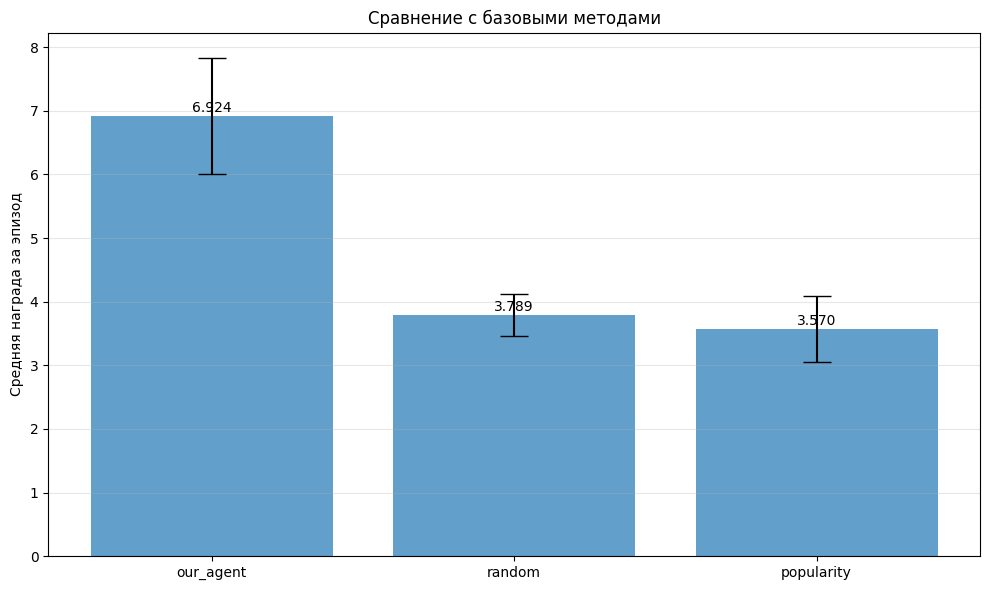


Результаты сравнения:
  our_agent: 6.924 ± 0.912
  random: 3.789 ± 0.328
  popularity: 3.570 ± 0.524

----------------------------------------
ВИЗУАЛИЗАЦИЯ РЕЗУЛЬТАТОВ
----------------------------------------


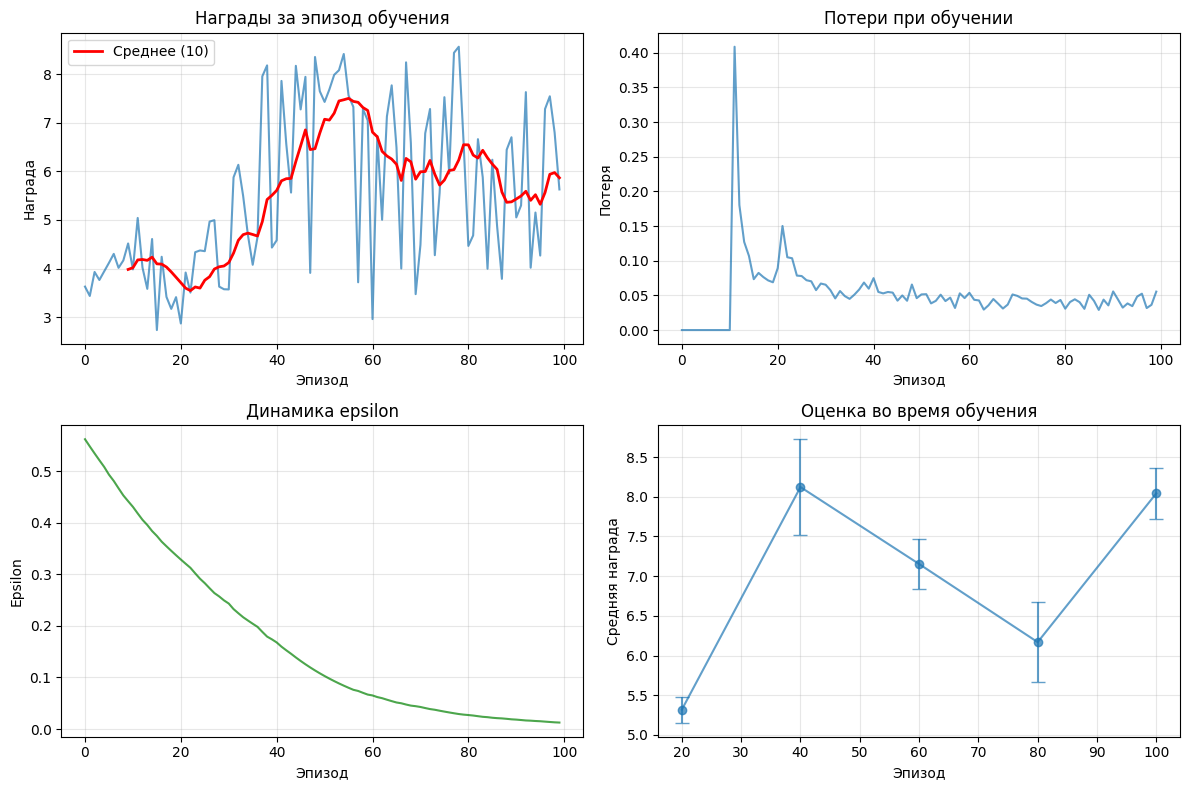

In [8]:
# Создание буфера и тренера для экспериментов
replay_buffer = PrioritizedReplayBuffer(
    capacity=REPLAY_BUFFER_CONFIG['capacity'],
    alpha=REPLAY_BUFFER_CONFIG['alpha'],
    beta=REPLAY_BUFFER_CONFIG['beta']
)

trainer = DQNTrainer(env, dqn_agent, replay_buffer, TRAIN_CONFIG)

# Загрузка состояния тренера если есть
if os.path.exists('../data/models/dqn_agent_checkpoint.pth'):
    trainer.load_checkpoint('../data/models/dqn_agent_checkpoint.pth')

# Создание runner
experiment_runner = ExperimentRunner(trainer, env)

# Эксперимент 1: Обучение
print("\n" + "-"*40)
print("ЭКСПЕРИМЕНТ 1: ОБУЧЕНИЕ АГЕНТА")
print("-"*40)

training_results = experiment_runner.run_training_experiment(
    n_episodes=100,  # Можно увеличить для полного обучения
    eval_interval=20
)

# Эксперимент 2: Сравнение с базовыми методами
print("\n" + "-"*40)
print("ЭКСПЕРИМЕНТ 2: СРАВНЕНИЕ С БАЗОВЫМИ МЕТОДАМИ")
print("-"*40)

comparison_results = experiment_runner.compare_with_baselines()

print("\nРезультаты сравнения:")
for method, scores in comparison_results.items():
    print(f"  {method}: {scores['mean_reward']:.3f} ± {scores.get('std_reward', 0):.3f}")

# Визуализация прогресса
print("\n" + "-"*40)
print("ВИЗУАЛИЗАЦИЯ РЕЗУЛЬТАТОВ")
print("-"*40)

experiment_runner.plot_training_progress()

## 4. Сравнительное тестирование


СРАВНИТЕЛЬНОЕ ТЕСТИРОВАНИЕ МОДЕЛЕЙ

Запуск тестов на 20 пользователях...
СРАВНИТЕЛЬНОЕ ТЕСТИРОВАНИЕ МОДЕЛЕЙ

Пользователь 1/20
  Random: Precision=0.000, Reward=0.587
  Popularity: Precision=0.300, Reward=0.628
  DeepFM-SVD++ (Static): Precision=0.300, Reward=0.782
Эпизод начат: User 336, Context {'class': 1, 'semester': 0, 'lockdown': 1}
Эпизод начат: User 336, Context {'class': 1, 'semester': 0, 'lockdown': 1}
  DQN-Enhanced: Precision=0.000, Reward=7.464

Пользователь 2/20
  Random: Precision=0.300, Reward=0.706
  Popularity: Precision=0.400, Reward=0.773
  DeepFM-SVD++ (Static): Precision=0.300, Reward=0.811
Эпизод начат: User 175, Context {'class': 0, 'semester': 1, 'lockdown': 2}
Эпизод начат: User 175, Context {'class': 0, 'semester': 1, 'lockdown': 2}
  DQN-Enhanced: Precision=0.200, Reward=6.789

Пользователь 3/20
  Random: Precision=0.600, Reward=0.766
  Popularity: Precision=0.600, Reward=0.754
  DeepFM-SVD++ (Static): Precision=0.400, Reward=0.841
Эпизод начат: User 229, C

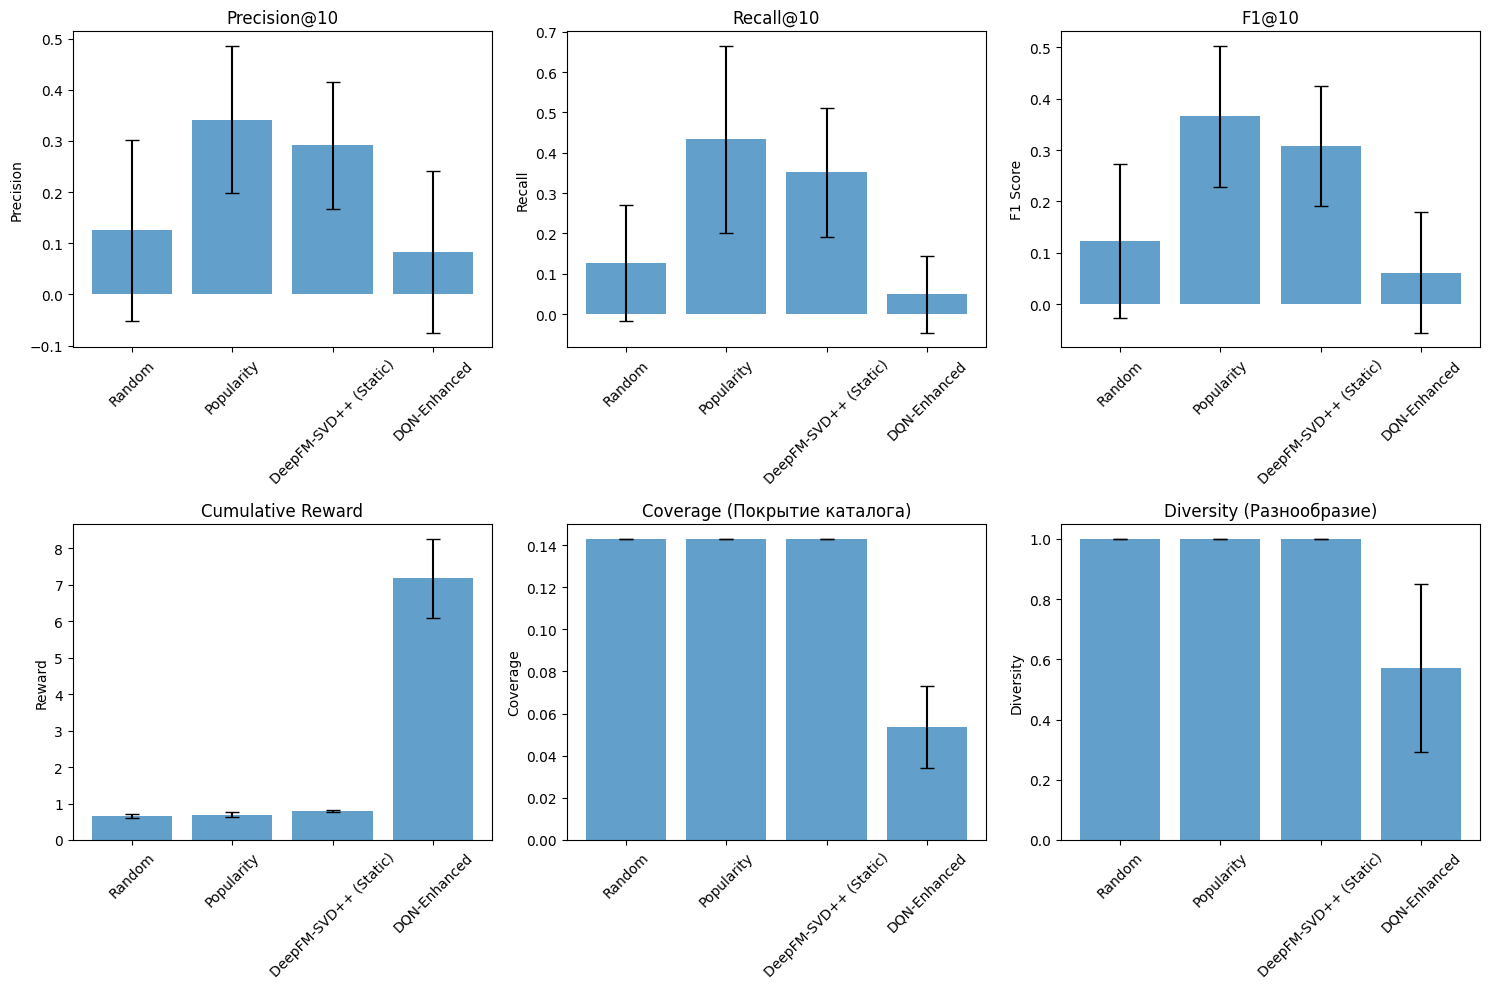


СВОДНАЯ ТАБЛИЦА РЕЗУЛЬТАТОВ
                Model  Precision@10     Recall@10         F1@10 Cumulative_Reward      Coverage     Diversity
               Random 0.125 ± 0.176 0.127 ± 0.144 0.122 ± 0.150     0.659 ± 0.061 0.143 ± 0.000 1.000 ± 0.000
           Popularity 0.342 ± 0.144 0.433 ± 0.232 0.366 ± 0.137     0.697 ± 0.078 0.143 ± 0.000 1.000 ± 0.000
DeepFM-SVD++ (Static) 0.292 ± 0.124 0.351 ± 0.159 0.307 ± 0.117     0.786 ± 0.028 0.143 ± 0.000 1.000 ± 0.000
         DQN-Enhanced 0.083 ± 0.159 0.049 ± 0.096 0.061 ± 0.118     7.181 ± 1.079 0.054 ± 0.019 0.572 ± 0.280

СРАВНИТЕЛЬНОЕ ТЕСТИРОВАНИЕ ЗАВЕРШЕНО!


In [9]:
print("\n" + "="*60)
print("СРАВНИТЕЛЬНОЕ ТЕСТИРОВАНИЕ МОДЕЛЕЙ")
print("="*60)

# Инициализация сравнительного тестирования
tester = ComparativeTester(env, model, dqn_agent, dataset)

# Запуск тестов
print("\nЗапуск тестов на 20 пользователях...")
aggregated_results = tester.run_comparative_test(
    test_users=20,
    recommendations_per_user=10
)

# Визуализация результатов
print("\nВизуализация результатов...")
summary_df = tester.visualize_results(aggregated_results)

print("\n" + "="*60)
print("СРАВНИТЕЛЬНОЕ ТЕСТИРОВАНИЕ ЗАВЕРШЕНО!")
print("="*60)

## 5. Долгосрочная оценка


Оценка долгосрочной производительности DQN агента...
Эпизод начат: User 4, Context {'class': 0, 'semester': 0, 'lockdown': 2}
Эпизод начат: User 444, Context {'class': 2, 'semester': 1, 'lockdown': 1}
Эпизод начат: User 253, Context {'class': 0, 'semester': 1, 'lockdown': 2}
Эпизод начат: User 395, Context {'class': 0, 'semester': 0, 'lockdown': 2}
Эпизод начат: User 36, Context {'class': 0, 'semester': 1, 'lockdown': 2}
Эпизод начат: User 406, Context {'class': 0, 'semester': 0, 'lockdown': 2}
Эпизод начат: User 379, Context {'class': 0, 'semester': 1, 'lockdown': 2}
Эпизод начат: User 310, Context {'class': 0, 'semester': 0, 'lockdown': 2}
Эпизод начат: User 195, Context {'class': 0, 'semester': 0, 'lockdown': 2}
Эпизод начат: User 248, Context {'class': 0, 'semester': 0, 'lockdown': 2}
Эпизод начат: User 281, Context {'class': 0, 'semester': 0, 'lockdown': 2}
Эпизод начат: User 81, Context {'class': 0, 'semester': 0, 'lockdown': 2}
Эпизод начат: User 159, Context {'class': 1, 'seme

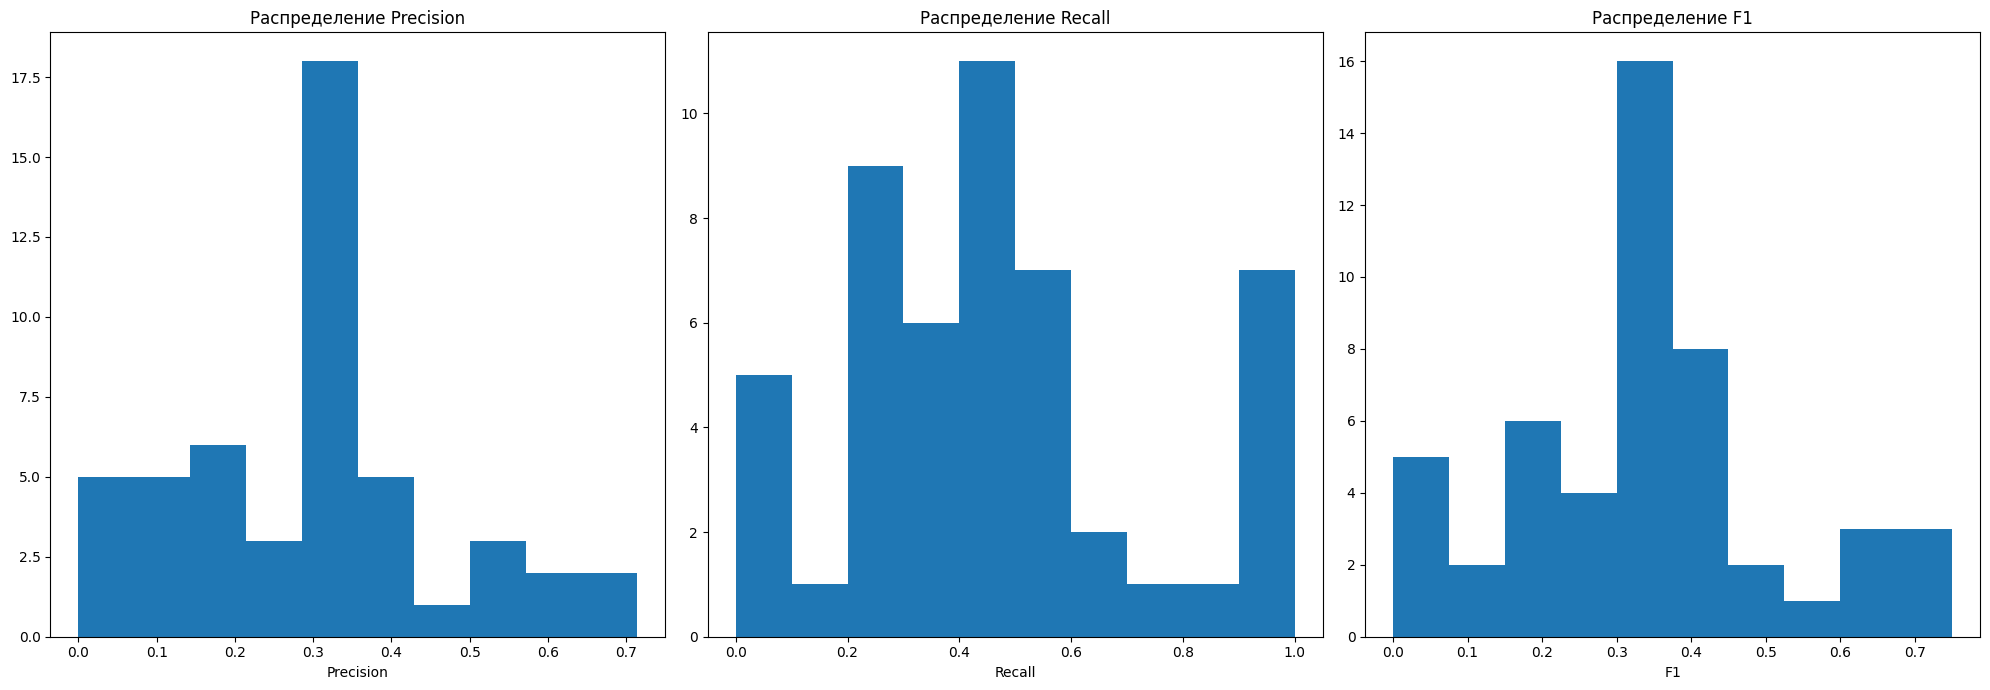

In [10]:
# Функции для долгосрочной оценки
def evaluate_long_term_performance(model, env, n_episodes=50, trajectory_length=100):
    """Оценка долгосрочной полезности на длинных траекториях"""
    all_precisions = []
    all_recalls = []
    all_f1_scores = []
    
    for episode in range(n_episodes):
        state = env.reset()
        recommended_items = []
        relevant_items = []
        
        for step in range(trajectory_length):
            # Рекомендация
            action = model.get_action(state, epsilon=0.01)
            recommended_items.append(action)
            
            # Симуляция отклика
            next_state, reward, done, info = env.step(action)
            
            # Сбор ground truth
            if reward > 0.7:
                relevant_items.append(action)
            
            state = next_state
            if done:
                break
        
        # Расчет метрик
        k = min(50, len(recommended_items))
        true_positives = len(set(recommended_items[:k]) & set(relevant_items))
        
        precision = true_positives / k if k > 0 else 0
        recall = true_positives / len(relevant_items) if relevant_items else 0
        f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0
        
        all_precisions.append(precision)
        all_recalls.append(recall)
        all_f1_scores.append(f1)
    
    return {
        'precision_mean': np.mean(all_precisions),
        'precision_std': np.std(all_precisions),
        'precision_all': all_precisions,
        'recall_mean': np.mean(all_recalls),
        'recall_std': np.std(all_recalls),
        'recall_all': all_recalls,
        'f1_mean': np.mean(all_f1_scores),
        'f1_std': np.std(all_f1_scores),
        'f1': all_f1_scores,
    }

# Оценка долгосрочной производительности
print("\nОценка долгосрочной производительности DQN агента...")
res = evaluate_long_term_performance(dqn_agent, env, n_episodes=50, trajectory_length=100)

print(f"\nРезультаты долгосрочной оценки:")
print(f"Precision: {res['precision_mean']:.3f} ± {res['precision_std']:.3f}")
print(f"Recall: {res['recall_mean']:.3f} ± {res['recall_std']:.3f}")
print(f"F1: {res['f1_mean']:.3f} ± {res['f1_std']:.3f}")

# Визуализация распределений метрик
fig, ax = plt.subplots(nrows=1, ncols=3, figsize=(20, 7))

ax[0].hist(res['precision_all'])
ax[0].set_xlabel('Precision')
ax[0].set_title('Распределение Precision')

ax[1].hist(res['recall_all'])
ax[1].set_xlabel('Recall')
ax[1].set_title('Распределение Recall')

ax[2].hist(res['f1'])
ax[2].set_xlabel('F1')
ax[2].set_title('Распределение F1')

plt.tight_layout()
plt.show()

## 6. Оценка адаптивности

In [11]:
def evaluate_adaptability(model, env, preference_shifts=3):
    """Оценка способности адаптироваться к изменяющимся предпочтениям"""
    
    results = []
    
    for shift in range(preference_shifts):
        # Симуляция изменения предпочтений пользователя
        env.current_context = {
            'class': np.random.randint(0, 3),
            'semester': (env.current_context['semester'] + 1) % 2,
            'lockdown': np.random.randint(0, 3)
        }
        
        # Оценка после смены предпочтений
        eval_results = evaluate_long_term_performance(
            model, env, n_episodes=10, trajectory_length=30
        )
        eval_results['shift'] = shift
        results.append(eval_results)
    
    # Анализ устойчивости метрик
    precisions = [r['precision_mean'] for r in results]
    recalls = [r['recall_mean'] for r in results]
    
    adaptability_score = 1 - (np.std(precisions) + np.std(recalls)) / 2
    
    return {
        'results': results,
        'adaptability_score': adaptability_score,
        'precision_stability': np.std(precisions),
        'recall_stability': np.std(recalls)
    }

# Оценка адаптивности
print("\nОценка адаптивности агента...")
res_adapt = evaluate_adaptability(dqn_agent, env)

print(f"\nРезультаты оценки адаптивности:")
print(f"Адаптивность агента: {res_adapt['adaptability_score']:.3f}")
print(f"Стабильность Precision: {res_adapt['precision_stability']:.3f}")
print(f"Стабильность Recall: {res_adapt['recall_stability']:.3f}")


Оценка адаптивности агента...
Эпизод начат: User 157, Context {'class': 2, 'semester': 0, 'lockdown': 1}
Эпизод начат: User 379, Context {'class': 0, 'semester': 1, 'lockdown': 2}
Эпизод начат: User 235, Context {'class': 0, 'semester': 0, 'lockdown': 0}
Эпизод начат: User 423, Context {'class': 0, 'semester': 0, 'lockdown': 2}
Эпизод начат: User 38, Context {'class': 1, 'semester': 1, 'lockdown': 2}
Эпизод начат: User 416, Context {'class': 0, 'semester': 0, 'lockdown': 2}
Эпизод начат: User 418, Context {'class': 2, 'semester': 0, 'lockdown': 2}
Эпизод начат: User 453, Context {'class': 0, 'semester': 0, 'lockdown': 2}
Эпизод начат: User 273, Context {'class': 2, 'semester': 1, 'lockdown': 1}
Эпизод начат: User 228, Context {'class': 0, 'semester': 1, 'lockdown': 2}
Эпизод начат: User 348, Context {'class': 1, 'semester': 0, 'lockdown': 1}
Эпизод начат: User 99, Context {'class': 0, 'semester': 0, 'lockdown': 2}
Эпизод начат: User 362, Context {'class': 0, 'semester': 0, 'lockdown':

## 7. Долгосрочная оценка с LongTermEvaluator

Запуск долгосрочной оценки полезности...

Тестирование DQN...
Эпизод начат: User 87, Context {'class': 0, 'semester': 1, 'lockdown': 2}
Эпизод начат: User 198, Context {'class': 0, 'semester': 0, 'lockdown': 2}
Эпизод начат: User 279, Context {'class': 0, 'semester': 0, 'lockdown': 2}
Эпизод начат: User 229, Context {'class': 0, 'semester': 0, 'lockdown': 2}
Эпизод начат: User 141, Context {'class': 0, 'semester': 0, 'lockdown': 2}
Эпизод начат: User 45, Context {'class': 1, 'semester': 0, 'lockdown': 1}
Эпизод начат: User 122, Context {'class': 0, 'semester': 0, 'lockdown': 2}
Эпизод начат: User 18, Context {'class': 0, 'semester': 0, 'lockdown': 2}
Эпизод начат: User 391, Context {'class': 2, 'semester': 1, 'lockdown': 1}
Эпизод начат: User 324, Context {'class': 2, 'semester': 0, 'lockdown': 2}
Эпизод начат: User 407, Context {'class': 0, 'semester': 0, 'lockdown': 2}
Эпизод начат: User 330, Context {'class': 0, 'semester': 0, 'lockdown': 2}
Эпизод начат: User 383, Context {'class':

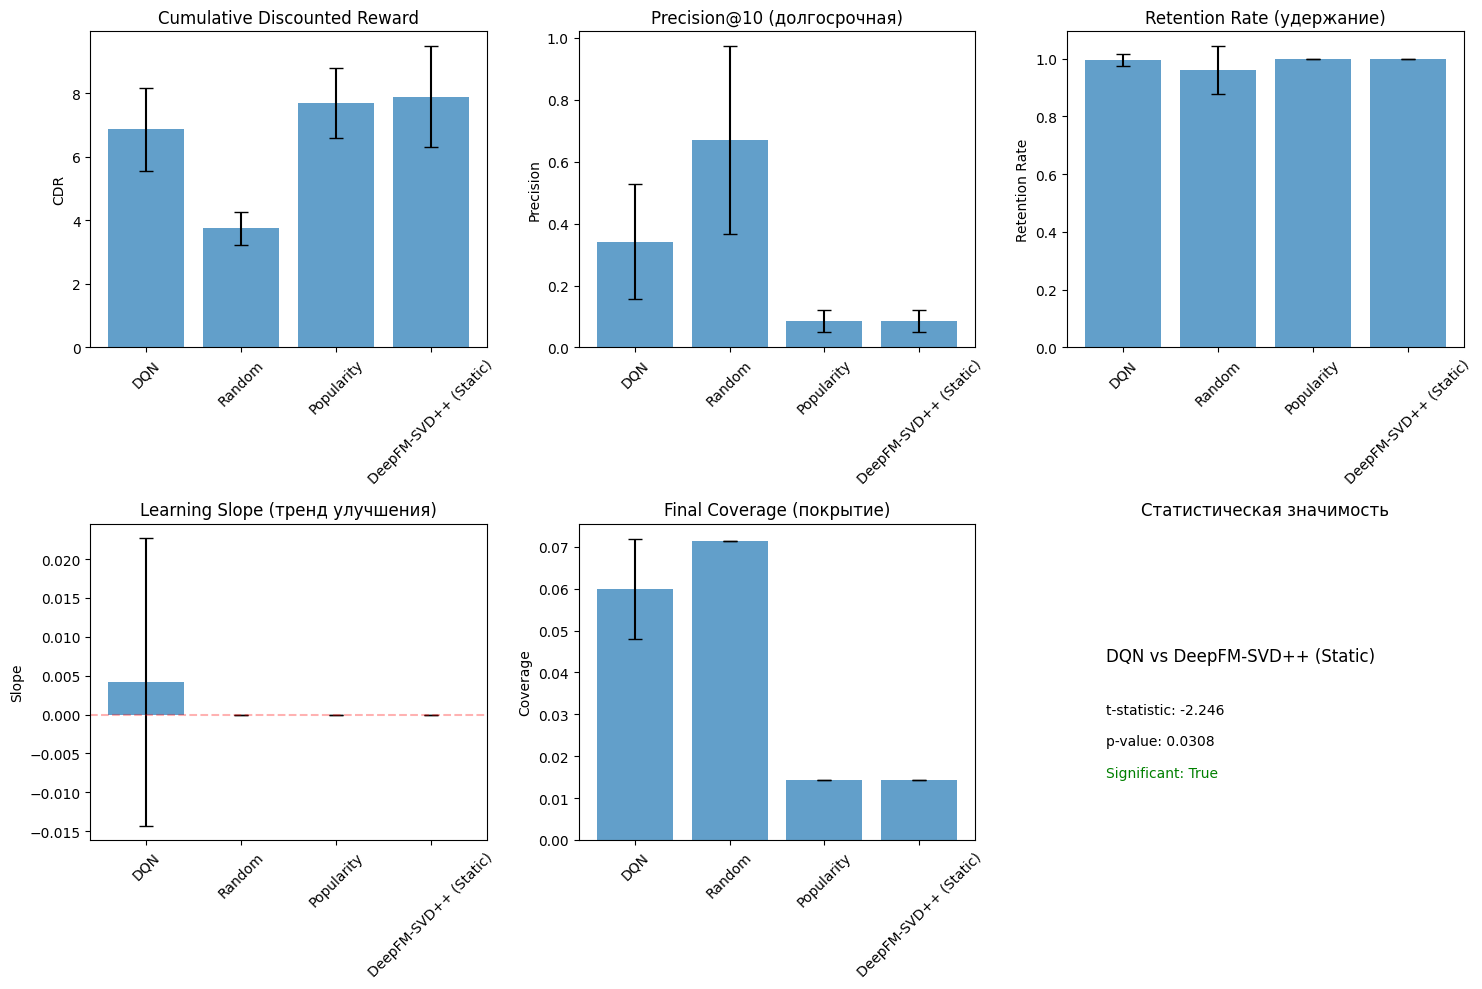

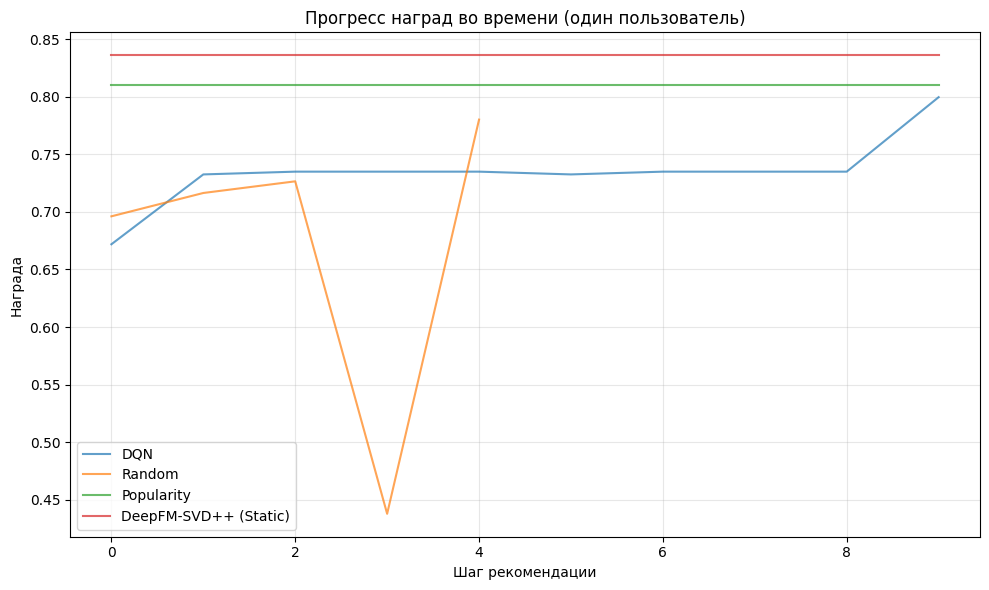


АНАЛИЗ ДОЛГОСРОЧНОЙ ПОЛЕЗНОСТИ

DQN:
  Cumulative Discounted Reward: 6.863 (±1.319)
  Precision@10: 0.341
  Retention Rate: 0.995
  Learning Slope: 0.004 (улучшение)

Random:
  Cumulative Discounted Reward: 3.754 (±0.515)
  Precision@10: 0.670
  Retention Rate: 0.960
  Learning Slope: 0.000 (ухудшение)

Popularity:
  Cumulative Discounted Reward: 7.696 (±1.092)
  Precision@10: 0.085
  Retention Rate: 1.000
  Learning Slope: -0.000 (ухудшение)

DeepFM-SVD++ (Static):
  Cumulative Discounted Reward: 7.897 (±1.581)
  Precision@10: 0.085
  Retention Rate: 1.000
  Learning Slope: -0.000 (ухудшение)


In [111]:
# Создание базовых моделей для сравнения
def random_recommender(user_id, context, k=1):
    return [np.random.randint(0, dataset.n_items) for _ in range(k)]

def popularity_recommender(user_id, context, k=1):
    item_popularity = dataset.ratings['ItemID_encoded'].value_counts()
    popular_items = item_popularity.index[:k].tolist()
    return popular_items

def static_deepfm_recommender(user_id, context, k=1):
    device = model.device
    item_ids = torch.arange(dataset.n_items).long().to(device)
    user_ids = torch.LongTensor([user_id] * dataset.n_items).to(device)
    class_ids = torch.LongTensor([context['class']] * dataset.n_items).to(device)
    semester_ids = torch.LongTensor([context['semester']] * dataset.n_items).to(device)
    lockdown_ids = torch.LongTensor([context['lockdown']] * dataset.n_items).to(device)
    
    with torch.no_grad():
        predictions = model(user_ids, item_ids, class_ids, semester_ids, lockdown_ids)
        scores = (0.5 * predictions['rating'] + 
                 0.3 * predictions['app'] + 
                 0.15 * predictions['data'] + 
                 0.05 * predictions['ease'])
        top_indices = torch.topk(scores, k).indices.cpu().numpy()
        return top_indices.tolist()

# Запуск долгосрочной оценки
print("Запуск долгосрочной оценки полезности...")

long_term_evaluator = LongTermEvaluator(
    env=env,
    dqn_agent=dqn_agent,
    baseline_models={
        'Random': random_recommender,
        'Popularity': popularity_recommender,
        'DeepFM-SVD++ (Static)': static_deepfm_recommender
    }
)

long_term_results = long_term_evaluator.run_long_term_experiment(
    n_users=20,
    trajectory_length=100
)

print("\nВизуализация долгосрочных результатов...")
long_term_evaluator.visualize_long_term_results(long_term_results)

# Анализ результатов
print("\n" + "="*60)
print("АНАЛИЗ ДОЛГОСРОЧНОЙ ПОЛЕЗНОСТИ")
print("="*60)

for model_name, results in long_term_results.items():
    mean = results['mean']
    print(f"\n{model_name}:")
    print(f"  Cumulative Discounted Reward: {mean['CDR']:.3f} (±{results['std']['CDR']:.3f})")
    print(f"  Precision@10: {mean['Precision@10']:.3f}")
    print(f"  Retention Rate: {mean['Retention_Rate']:.3f}")
    print(f"  Learning Slope: {mean['Learning_Slope']:.3f} {'(улучшение)' if mean['Learning_Slope'] > 0 else '(ухудшение)'}")

## 8. Сохранение результатов

Все результаты тестирования можно сохранить для дальнейшего анализа.

In [112]:
# Сохранение результатов
import json

results_to_save = {
    'training_summary': {
        'final_epsilon': trainer.epsilon,
        'total_episodes': len(training_results['training_rewards']),
        'mean_training_reward': np.mean(training_results['training_rewards'][-10:]),
        'best_evaluation': max([score['mean_reward'] 
                              for score in training_results['evaluation_scores']]) if training_results['evaluation_scores'] else 0
    },
    'comparison_results': {
        k: {'mean_reward': v['mean_reward'], 'std_reward': v.get('std_reward', 0)}
        for k, v in comparison_results.items()
    },
    'long_term_metrics': {
        k: {
            'CDR': float(v['mean']['CDR']),
            'Precision@10': float(v['mean']['Precision@10']),
            'Retention_Rate': float(v['mean']['Retention_Rate'])
        }
        for k, v in long_term_results.items()
    },
    'adaptability': {
        'adaptability_score': float(res_adapt['adaptability_score']),
        'precision_stability': float(res_adapt['precision_stability']),
        'recall_stability': float(res_adapt['recall_stability'])
    }
}

os.makedirs('../results', exist_ok=True)
with open('../results/test_results.json', 'w') as f:
    json.dump(results_to_save, f, indent=2)

print("Результаты сохранены в results/test_results.json")

Результаты сохранены в results/test_results.json
